# Topic: Supply Chain Risk Digital Twin
**Students:**  
- Bekithemba Nkomo  
- Masheia Dzimba
- Peter Mangoro

The goal is to represent suppliers, products, and supplier geography as a knowledge graph and then use Cypher and Neo4j Graph Data Science (GDS) to identify high-risk suppliers, risk-concentrated products (single points of failure), and risk clusters by geography.

The desired outcome is an interpretable, network-based view of supply chain vulnerability that supports scenario-style questions such as:

- Which suppliers/products should be prioritized for mitigation?
- Where are systemic risks concentrated?

The solution will be implemented in Neo4j (Desktop), queried in Cypher, and analyzed with at least one GDS workflow in a Jupyter Notebook deliverable.

In [1]:
import sys
from pathlib import Path
import os

import neo4j
import pandas as pd
import matplotlib
import seaborn as sns

print("Python:", sys.executable)
print("CWD:", Path.cwd())
print("neo4j", neo4j.__version__, "| pandas", pd.__version__)
for key in ("NEO4J_URI", "NEO4J_USER", "NEO4J_PASSWORD"):
    print(f"{key}:", "set" if os.environ.get(key) else "(not set)")


Python: /home/themad/Documents/yeshiva/capstone/neo4j/finalProject/.venv/bin/python
CWD: /home/themad/Documents/yeshiva/capstone/neo4j/finalProject
neo4j 6.1.0 | pandas 3.0.1
NEO4J_URI: set
NEO4J_USER: set
NEO4J_PASSWORD: set


## Phase 1a — Column extraction & graph mapping

Before constraints and ingestion we **inventory the CSV** and map each field to **nodes** and **relationships**. This table drives `MERGE` keys and `:SUPPLIES` properties in later phases.

Run the next cell with working directory `finalProject` so the path to `dynamic_supply_chain_logistics_dataset_with_country.csv` resolves.


In [2]:
from pathlib import Path

import pandas as pd

DATA_CSV = Path("dynamic_supply_chain_logistics_dataset_with_country.csv")
if not DATA_CSV.is_file():
    raise FileNotFoundError(
        f"Expected {DATA_CSV.resolve()} — run the notebook with cwd finalProject or adjust DATA_CSV."
    )

# --- 1) Column names (header-only read is fast)
header = pd.read_csv(DATA_CSV, nrows=0)
columns = list(header.columns)
print(f"Dataset: {DATA_CSV.name}\nColumn count: {len(columns)}\n")
for i, col in enumerate(columns, 1):
    print(f"{i:2d}. {col}")

# --- 2) dtypes from a sample (full file is ~113k rows)
sample = pd.read_csv(DATA_CSV, nrows=10)
print("\nDtypes (from first 10 rows):\n")
print(sample.dtypes)
print(sample)

# --- 3) Graph mapping: single source of truth for Neo4j model
#     Adjust graph_property if you rename keys on nodes (e.g. Supplier.id from supplier_id).
rows = [
    ("supplier_id", "identifier", "Supplier", "id", "MERGE key; also used for LOCATED_IN + SUPPLIES"),
    ("product_id", "identifier", "Product", "id", "MERGE key for SUPPLIES"),
    ("supplier_country", "identifier", "Country", "name", "MERGE key on Country; edge Supplier→Country"),
    ("warehouse_inventory_level", "numeric", "SUPPLIES", "warehouse_inventory_level", "relationship property; aggregate if duplicate pairs"),
    ("handling_equipment_availability", "numeric", "SUPPLIES", "handling_equipment_availability", "aggregate"),
    ("order_fulfillment_status", "numeric", "SUPPLIES", "order_fulfillment_status", "aggregate"),
    ("weather_condition_severity", "numeric", "SUPPLIES", "weather_condition_severity", "aggregate"),
    ("shipping_costs", "numeric", "SUPPLIES", "shipping_costs", "aggregate"),
    ("supplier_reliability_score", "numeric", "SUPPLIES", "supplier_reliability_score", "aggregate"),
    ("lead_time_days", "numeric", "SUPPLIES", "lead_time_days", "aggregate"),
    ("historical_demand", "numeric", "SUPPLIES", "historical_demand", "aggregate"),
    ("cargo_condition_status", "numeric", "SUPPLIES", "cargo_condition_status", "aggregate"),
    ("route_risk_level", "numeric", "SUPPLIES", "route_risk_level", "aggregate"),
    ("customs_clearance_time", "numeric", "SUPPLIES", "customs_clearance_time", "aggregate"),
    ("disruption_likelihood_score", "numeric", "SUPPLIES", "disruption_likelihood_score", "aggregate"),
    ("delay_probability", "numeric", "SUPPLIES", "delay_probability", "aggregate"),
    ("risk_classification", "categorical", "SUPPLIES", "risk_classification", "aggregate (e.g. mode) or omit"),
    ("delivery_time_deviation", "numeric", "SUPPLIES", "delivery_time_deviation", "aggregate"),
]
graph_map = pd.DataFrame(
    rows,
    columns=["csv_column", "role", "neo4j_element", "graph_property", "notes"],
)

mapped = set(graph_map["csv_column"])
missing = [c for c in columns if c not in mapped]
extra = [c for c in mapped if c not in columns]
if missing:
    print("WARNING: CSV columns not in mapping table:", missing)
if extra:
    print("WARNING: mapping entries not in CSV:", extra)
if not missing and not extra:
    print("Mapping table covers all", len(columns), "CSV columns.")

graph_map


Dataset: dynamic_supply_chain_logistics_dataset_with_country.csv
Column count: 18

 1. warehouse_inventory_level
 2. handling_equipment_availability
 3. order_fulfillment_status
 4. weather_condition_severity
 5. shipping_costs
 6. supplier_reliability_score
 7. lead_time_days
 8. historical_demand
 9. cargo_condition_status
10. route_risk_level
11. customs_clearance_time
12. disruption_likelihood_score
13. delay_probability
14. risk_classification
15. delivery_time_deviation
16. product_id
17. supplier_id
18. supplier_country

Dtypes (from first 10 rows):

warehouse_inventory_level          float64
handling_equipment_availability    float64
order_fulfillment_status           float64
weather_condition_severity         float64
shipping_costs                     float64
supplier_reliability_score         float64
lead_time_days                     float64
historical_demand                  float64
cargo_condition_status             float64
route_risk_level                   float64
custom

,csv_column,role,neo4j_element,graph_property,notes
0,supplier_id,identifier,Supplier,id,MERGE key; also used for LOCATED_IN + SUPPLIES
1,product_id,identifier,Product,id,MERGE key for SUPPLIES
2,supplier_country,identifier,Country,name,MERGE key on Country; edge Supplier→Country
3,warehouse_inventory_level,numeric,SUPPLIES,warehouse_inventory_level,relationship property; aggregate if duplicate ...
4,handling_equipment_availability,numeric,SUPPLIES,handling_equipment_availability,aggregate
5,order_fulfillment_status,numeric,SUPPLIES,order_fulfillment_status,aggregate
6,weather_condition_severity,numeric,SUPPLIES,weather_condition_severity,aggregate
7,shipping_costs,numeric,SUPPLIES,shipping_costs,aggregate
8,supplier_reliability_score,numeric,SUPPLIES,supplier_reliability_score,aggregate
9,lead_time_days,numeric,SUPPLIES,lead_time_days,aggregate


## Phase 1b — Neo4j connection & uniqueness constraints

- Loads credentials from `.env` in `finalProject` (`NEO4J_URI`, `NEO4J_USER`, `NEO4J_PASSWORD`). Do not commit `.env` (it is gitignored).
- Creates uniqueness constraints on `Supplier.id`, `Product.id`, `Country.name`, and `Observation.observation_id` so ingestion `MERGE` operations are idempotent.
- Start your Neo4j instance before running the next cell.


In [3]:
import os
from pathlib import Path

from dotenv import load_dotenv
from neo4j import GraphDatabase
import pandas as pd

load_dotenv(Path.cwd() / ".env")
uri = os.environ.get("NEO4J_URI")
user = os.environ.get("NEO4J_USER")
password = os.environ.get("NEO4J_PASSWORD")
if not all([uri, user, password]):
    raise RuntimeError("Set NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD in finalProject/.env")

driver = GraphDatabase.driver(uri, auth=(user, password))
driver.verify_connectivity()
print("Connected to", uri)


def run_cypher(cypher: str, **params):
    with driver.session() as session:
        result = session.run(cypher, **params)
        return [r.data() for r in result]


def run_cypher_frame(cypher: str, **params):
    return pd.DataFrame(run_cypher(cypher, **params))


constraint_statements = [
    """
    CREATE CONSTRAINT supplier_id_unique IF NOT EXISTS
    FOR (s:Supplier) REQUIRE s.id IS UNIQUE
    """,
    """
    CREATE CONSTRAINT product_id_unique IF NOT EXISTS
    FOR (p:Product) REQUIRE p.id IS UNIQUE
    """,
    """
    CREATE CONSTRAINT country_name_unique IF NOT EXISTS
    FOR (c:Country) REQUIRE c.name IS UNIQUE
    """,
    """
    CREATE CONSTRAINT observation_id_unique IF NOT EXISTS
    FOR (o:Observation) REQUIRE o.observation_id IS UNIQUE
    """,
]
for stmt in constraint_statements:
    run_cypher(stmt.strip())
print("Constraints applied.")
run_cypher_frame("SHOW CONSTRAINTS")


Connected to bolt://localhost:7687
Constraints applied.


,id,name,type,entityType,labelsOrTypes,properties,enforcedLabel,ownedIndex,propertyType
0,7,country_name_unique,NODE_PROPERTY_UNIQUENESS,NODE,[Country],[name],None,country_name_unique,None
1,9,observation_id_unique,NODE_PROPERTY_UNIQUENESS,NODE,[Observation],[observation_id],None,observation_id_unique,None
2,5,product_id_unique,NODE_PROPERTY_UNIQUENESS,NODE,[Product],[id],None,product_id_unique,None
3,3,supplier_id_unique,NODE_PROPERTY_UNIQUENESS,NODE,[Supplier],[id],None,supplier_id_unique,None


## Phase 2a — Dataset validation (pandas)

Loads the full primary CSV from `finalProject` (same file you copy into Neo4j’s **import** folder for `LOAD CSV`). Checks nulls, cardinalities, and duplicate `(supplier_id, product_id)` rows that ingestion will aggregate.


In [4]:
from pathlib import Path

import pandas as pd

DATA_CSV = Path("dynamic_supply_chain_logistics_dataset_with_country.csv")
df = pd.read_csv(DATA_CSV)
print("Rows:", len(df))
print("\nNull counts:\n", df.isna().sum())
print(
    "\nUniques:",
    {c: int(df[c].nunique()) for c in ["supplier_id", "product_id", "supplier_country"]},
)
pair_counts = df.groupby(["supplier_id", "product_id"], dropna=False).size()
dup_pairs = pair_counts[pair_counts > 1]



Rows: 113097

Null counts:
 warehouse_inventory_level          0
handling_equipment_availability    0
order_fulfillment_status           0
weather_condition_severity         0
shipping_costs                     0
supplier_reliability_score         0
lead_time_days                     0
historical_demand                  0
cargo_condition_status             0
route_risk_level                   0
customs_clearance_time             0
disruption_likelihood_score        0
delay_probability                  0
risk_classification                0
delivery_time_deviation            0
product_id                         0
supplier_id                        0
supplier_country                   0
dtype: int64

Uniques: {'supplier_id': 3524, 'product_id': 1000, 'supplier_country': 94}


## Phase 2b — Hybrid ingestion into Neo4j (`LOAD CSV`)

**Prerequisites:** `dynamic_supply_chain_logistics_dataset_with_country.csv` is in the Neo4j **import** directory (same filename as in `file:///...` below). Constraints from Phase 1b must exist.

- **Hybrid model:**
  - One `:Observation` node per CSV row (raw values for drill-down).
  - One aggregated `(:Supplier)-[:SUPPLIES]->(:Product)` lane per pair with:
    - `observation_count`
    - risk shares (`risk_high_share`, `risk_moderate_share`, `risk_low_share`)
    - `risk_classification_mode`
    - averaged numeric metrics
- **Optional wipe:** Set `CLEAR_GRAPH_BEFORE_LOAD = True` only on a **development** database to delete all existing nodes and relationships before reloading.


In [5]:
from IPython.display import display

# Hybrid ingestion:
# 1) load raw rows as Observation nodes
# 2) aggregate one SUPPLIES lane per (Supplier, Product)
CLEAR_GRAPH_BEFORE_LOAD = True

if CLEAR_GRAPH_BEFORE_LOAD:
    run_cypher("MATCH (n) DETACH DELETE n")
    print("Graph cleared.")

OBSERVATION_LOAD_CYPHER = """
LOAD CSV WITH HEADERS FROM 'file:///dynamic_supply_chain_logistics_dataset_with_country.csv' AS raw
WITH raw
WHERE raw.supplier_id IS NOT NULL
  AND raw.product_id IS NOT NULL
  AND raw.supplier_country IS NOT NULL
WITH
  trim(raw.supplier_country) AS country,
  trim(raw.supplier_id) AS sid,
  trim(raw.product_id) AS pid,
  trim(raw.risk_classification) AS risk_class,
  raw AS row
MERGE (c:Country {name: country})
MERGE (s:Supplier {id: sid})
MERGE (p:Product {id: pid})
MERGE (s)-[:LOCATED_IN]->(c)
MERGE (o:Observation {observation_id: sid + '|' + pid + '|' + toString(linenumber())})
SET o.risk_classification = risk_class,
    o.warehouse_inventory_level = toFloat(row.warehouse_inventory_level),
    o.handling_equipment_availability = toFloat(row.handling_equipment_availability),
    o.order_fulfillment_status = toFloat(row.order_fulfillment_status),
    o.weather_condition_severity = toFloat(row.weather_condition_severity),
    o.shipping_costs = toFloat(row.shipping_costs),
    o.supplier_reliability_score = toFloat(row.supplier_reliability_score),
    o.lead_time_days = toFloat(row.lead_time_days),
    o.historical_demand = toFloat(row.historical_demand),
    o.cargo_condition_status = toFloat(row.cargo_condition_status),
    o.route_risk_level = toFloat(row.route_risk_level),
    o.customs_clearance_time = toFloat(row.customs_clearance_time),
    o.disruption_likelihood_score = toFloat(row.disruption_likelihood_score),
    o.delay_probability = toFloat(row.delay_probability),
    o.delivery_time_deviation = toFloat(row.delivery_time_deviation)
MERGE (s)-[:HAS_OBSERVATION]->(o)
MERGE (o)-[:FOR_PRODUCT]->(p)
RETURN count(o) AS observations_loaded
"""

print("Loading Observation nodes...")
obs_result = run_cypher(OBSERVATION_LOAD_CYPHER.strip())
print(obs_result)

SUPPLIES_AGG_CYPHER = """
MATCH (s:Supplier)-[:HAS_OBSERVATION]->(o:Observation)-[:FOR_PRODUCT]->(p:Product)
WITH s, p,
     count(o) AS observation_count,
     avg(o.warehouse_inventory_level) AS warehouse_inventory_level,
     avg(o.handling_equipment_availability) AS handling_equipment_availability,
     avg(o.order_fulfillment_status) AS order_fulfillment_status,
     avg(o.weather_condition_severity) AS weather_condition_severity,
     avg(o.shipping_costs) AS shipping_costs,
     avg(o.supplier_reliability_score) AS supplier_reliability_score,
     avg(o.lead_time_days) AS lead_time_days,
     avg(o.historical_demand) AS historical_demand,
     avg(o.cargo_condition_status) AS cargo_condition_status,
     avg(o.route_risk_level) AS route_risk_level,
     avg(o.customs_clearance_time) AS customs_clearance_time,
     avg(o.disruption_likelihood_score) AS disruption_likelihood_score,
     avg(o.delay_probability) AS delay_probability,
     avg(o.delivery_time_deviation) AS delivery_time_deviation,
     sum(CASE WHEN o.risk_classification = 'High Risk' THEN 1 ELSE 0 END) AS high_n,
     sum(CASE WHEN o.risk_classification = 'Moderate Risk' THEN 1 ELSE 0 END) AS moderate_n,
     sum(CASE WHEN o.risk_classification = 'Low Risk' THEN 1 ELSE 0 END) AS low_n,
     collect(o.risk_classification) AS risk_labels
CALL {
  WITH risk_labels
  UNWIND risk_labels AS label
  WITH label, count(*) AS c
  ORDER BY c DESC, label
  RETURN label AS risk_classification_mode
  LIMIT 1
}
MERGE (s)-[r:SUPPLIES]->(p)
SET r.observation_count = observation_count,
    r.risk_high_share = 1.0 * high_n / observation_count,
    r.risk_moderate_share = 1.0 * moderate_n / observation_count,
    r.risk_low_share = 1.0 * low_n / observation_count,
    r.risk_classification_mode = risk_classification_mode,
    r.warehouse_inventory_level = warehouse_inventory_level,
    r.handling_equipment_availability = handling_equipment_availability,
    r.order_fulfillment_status = order_fulfillment_status,
    r.weather_condition_severity = weather_condition_severity,
    r.shipping_costs = shipping_costs,
    r.supplier_reliability_score = supplier_reliability_score,
    r.lead_time_days = lead_time_days,
    r.historical_demand = historical_demand,
    r.cargo_condition_status = cargo_condition_status,
    r.route_risk_level = route_risk_level,
    r.customs_clearance_time = customs_clearance_time,
    r.disruption_likelihood_score = disruption_likelihood_score,
    r.delay_probability = delay_probability,
    r.delivery_time_deviation = delivery_time_deviation
RETURN count(r) AS supplies_loaded
"""

print("Building aggregated SUPPLIES lanes...")
sup_result = run_cypher(SUPPLIES_AGG_CYPHER.strip())
print(sup_result)

print("Post-load counts:")
display(run_cypher_frame("MATCH (n) RETURN labels(n)[0] AS label, count(*) AS n ORDER BY label"))
display(run_cypher_frame("MATCH ()-[r]->() RETURN type(r) AS rel_type, count(*) AS n ORDER BY rel_type"))

print("Lane risk mode distribution (SUPPLIES):")
display(run_cypher_frame("""
MATCH ()-[r:SUPPLIES]->()
RETURN r.risk_classification_mode AS risk_class_mode, count(*) AS n
ORDER BY n DESC
"""))


Graph cleared.
Loading Observation nodes...
[{'observations_loaded': 113097}]
Building aggregated SUPPLIES lanes...


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is deprecated. Use CALL (risk_labels) { ... }', position=<SummaryInputPosition line=22, column=1, offset=1302>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 1302, 'line': 22, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "MATCH (s:Supplier)-[:HAS_OBSERVATION]->(o:Observation)-[:FOR_PRODUCT]->(p:Product)\nWITH s, p,\n     count(o) AS observation_count,\n     avg(o.warehouse_inventory_level) AS warehouse_inventory_level,\n     avg(o.handling_equipment_availability) AS handling_equipment_availability,\n     avg(o.order_fulfillment_status) AS order

[{'supplies_loaded': 3524}]
Post-load counts:


,label,n
0,Country,94
1,Observation,113097
2,Product,1000
3,Supplier,3524


,rel_type,n
0,FOR_PRODUCT,113097
1,HAS_OBSERVATION,113097
2,LOCATED_IN,3524
3,SUPPLIES,3524


Lane risk mode distribution (SUPPLIES):


,risk_class_mode,n
0,High Risk,3524


## Phase 3 — Exploratory data analysis (EDA)

Run **Phase 1b** first so `driver`, `run_cypher`, and `run_cypher_frame` exist. Each question below is one markdown cell + one code cell with Cypher → `DataFrame`.


### EDA Q1 — Graph composition
How many nodes and relationships exist in the hybrid graph (`Supplier`, `Product`, `Country`, `Observation`, and core relationship types)?


In [6]:
df = run_cypher_frame('''
MATCH (s:Supplier)
WITH count(s) AS suppliers
MATCH (p:Product)
WITH suppliers, count(p) AS products
MATCH (c:Country)
WITH suppliers, products, count(c) AS countries
MATCH (o:Observation)
WITH suppliers, products, countries, count(o) AS observations
MATCH ()-[x:SUPPLIES]->()
WITH suppliers, products, countries, observations, count(x) AS supplies
MATCH ()-[y:LOCATED_IN]->()
WITH suppliers, products, countries, observations, supplies, count(y) AS located_in
MATCH ()-[z:HAS_OBSERVATION]->()
WITH suppliers, products, countries, observations, supplies, located_in, count(z) AS has_observation
MATCH ()-[w:FOR_PRODUCT]->()
RETURN suppliers, products, countries, observations, supplies, located_in, has_observation, count(w) AS for_product
''')
display(df)



,suppliers,products,countries,observations,supplies,located_in,has_observation,for_product
0,3524,1000,94,113097,3524,3524,113097,113097


#### Narrative (Q1)
In the hybrid model, `SUPPLIES` relationships represent **aggregated supplier→product lanes** (one per `(supplier_id, product_id)`), while `Observation` nodes represent **raw CSV rows** for drill-down.

This check counts all major node types (`Supplier`, `Product`, `Country`, `Observation`) and major relationship types (`SUPPLIES`, `LOCATED_IN`, `HAS_OBSERVATION`, `FOR_PRODUCT`) to confirm the ingestion produced the expected lane graph plus the evidence layer.


### EDA Q2 — Observations per lane (`observation_count`)
How many raw observations are aggregated into each `SUPPLIES` lane (min/avg/max and distribution)?


,min_n,avg_n,max_n,p50,p90
0,16.0,32.09336,56.0,32.0,40.0


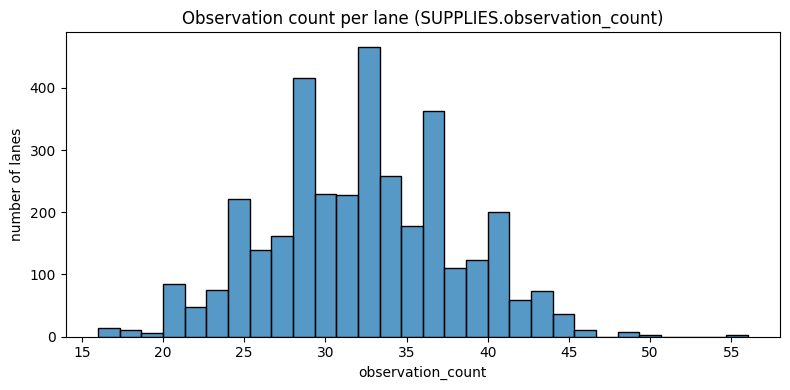

In [7]:
df = run_cypher_frame('''
MATCH ()-[r:SUPPLIES]->()
RETURN
  min(toFloat(r.observation_count)) AS min_n,
  avg(toFloat(r.observation_count)) AS avg_n,
  max(toFloat(r.observation_count)) AS max_n,
  percentileCont(toFloat(r.observation_count), 0.5) AS p50,
  percentileCont(toFloat(r.observation_count), 0.9) AS p90
''')
display(df)

# Distribution plot
df2 = run_cypher_frame('''
MATCH ()-[r:SUPPLIES]->()
RETURN toInteger(r.observation_count) AS n
''')

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
sns.histplot(df2['n'], bins=30, kde=False)
plt.title('Observation count per lane (SUPPLIES.observation_count)')
plt.xlabel('observation_count')
plt.ylabel('number of lanes')
plt.tight_layout()
plt.show()


#### Narrative (Q2)
Each `SUPPLIES` relationship stores `observation_count`, i.e., **how many CSV rows were aggregated** into that supplier→product lane.

Lanes with higher `observation_count` have more empirical support for their averaged metrics and risk shares, so comparisons are more trustworthy when `observation_count` is high.


### EDA Q3 — Risk class mix on lanes (mode)
Across aggregated lanes, what is the distribution of `risk_classification_mode`?


In [8]:
df = run_cypher_frame('''
MATCH ()-[r:SUPPLIES]->()
RETURN r.risk_classification_mode AS risk_class, count(*) AS n
ORDER BY n DESC
''')
display(df)




,risk_class,n
0,High Risk,3524


#### Narrative (Q3)
This chart uses `SUPPLIES.risk_classification_mode`, i.e., the **mode** risk class across all raw CSV observations aggregated into each lane.

Because lanes are aggregated, each lane contributes exactly one class to this distribution. If you want the raw row-level mix, query `Observation.risk_classification`.


### EDA Q4 — High-risk observation share by geography (weighted)
Which countries have the highest share of high-risk observations (weighted by lane `observation_count`)?


,country,lanes,total_obs,high_obs,high_share
0,Peru,23,678.0,534.0,0.787611
1,Ireland,34,1125.0,876.0,0.778667
2,Bolivia,31,1013.0,786.0,0.775913
3,Paraguay,35,1150.0,892.0,0.775652
4,Dominican Republic,55,1822.0,1412.0,0.774973
5,Belgium,33,1046.0,802.0,0.766730
6,Guatemala,36,1217.0,932.0,0.765818
7,Fiji,37,1205.0,921.0,0.764315
8,China,36,1233.0,940.0,0.762368
9,Bangladesh,43,1416.0,1078.0,0.761299


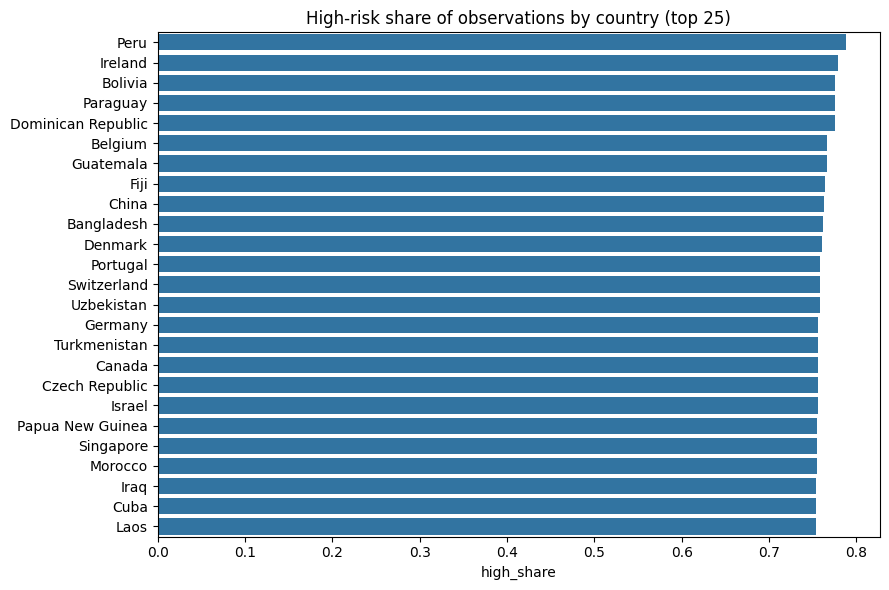

In [9]:
df = run_cypher_frame('''
MATCH (s:Supplier)-[r:SUPPLIES]->(:Product)
MATCH (s)-[:LOCATED_IN]->(c:Country)
WITH c.name AS country,
     count(r) AS lanes,
     sum(toFloat(r.observation_count)) AS total_obs,
     sum(r.risk_high_share * toFloat(r.observation_count)) AS high_obs
RETURN country, lanes, total_obs, high_obs,
       high_obs / total_obs AS high_share
ORDER BY high_share DESC
LIMIT 25
''')
display(df)

# Plot high-risk observation share by country
import matplotlib.pyplot as plt

plot_df = df.sort_values('high_share', ascending=False).copy()
plt.figure(figsize=(9, 6))
sns.barplot(data=plot_df, x='high_share', y='country', orient='h')
plt.title('High-risk share of observations by country (top 25)')
plt.xlabel('high_share')
plt.ylabel('')
plt.tight_layout()
plt.show()


#### Narrative (Q4)
Countries are ranked by the **observation-weighted** share of evidence labeled `High Risk`.

Each lane contributes `r.risk_high_share * r.observation_count`, so countries with many lanes and frequently high-risk lanes naturally rise to the top.


### EDA Q5 — Country risk ranking (weighted numeric metrics)
Which countries have the highest weighted average delay and disruption metrics?


,country,avg_delay,avg_disruption,lanes
0,Ireland,0.720544,0.828307,34
1,Peru,0.684714,0.825292,23
2,Dominican Republic,0.705028,0.824780,55
3,Belgium,0.700627,0.821092,33
4,Guatemala,0.687848,0.820653,36
5,Papua New Guinea,0.698470,0.819075,41
6,Bolivia,0.696672,0.818740,31
7,Paraguay,0.699923,0.817221,35
8,Denmark,0.715548,0.815919,40
9,Switzerland,0.694456,0.815773,35


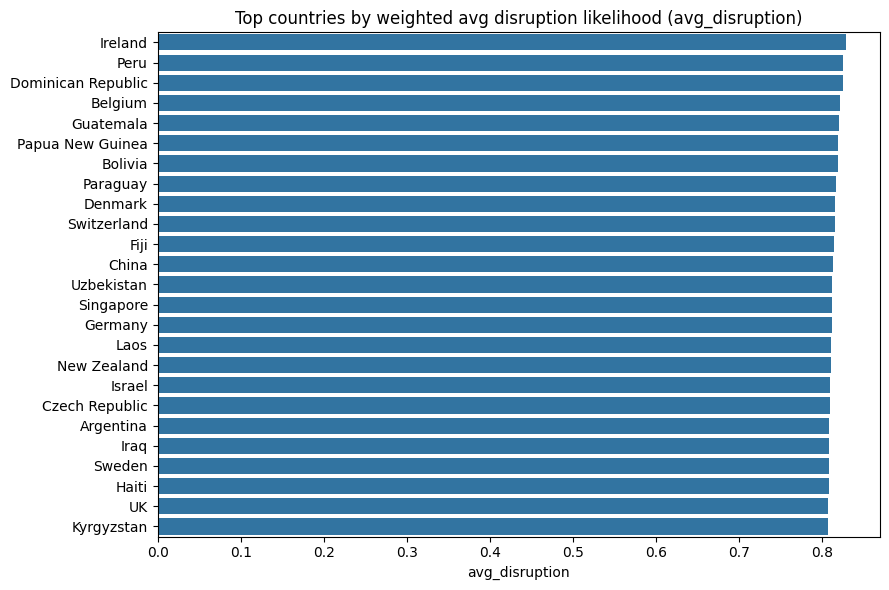

In [10]:
df = run_cypher_frame('''
MATCH (s:Supplier)-[r:SUPPLIES]->(:Product)
MATCH (s)-[:LOCATED_IN]->(c:Country)
WITH c.name AS country,
     // Weighted by how many raw observations each lane aggregates
     sum(r.delay_probability * toFloat(r.observation_count)) / sum(toFloat(r.observation_count)) AS avg_delay,
     sum(r.disruption_likelihood_score * toFloat(r.observation_count)) / sum(toFloat(r.observation_count)) AS avg_disruption,
     count(r) AS lanes
RETURN country, avg_delay, avg_disruption, lanes
ORDER BY avg_disruption DESC
LIMIT 25
''')
display(df)

# Plot country ranking by weighted disruption
import matplotlib.pyplot as plt

plot_df = df.sort_values('avg_disruption', ascending=False).copy()
plt.figure(figsize=(9, 6))
sns.barplot(data=plot_df, x='avg_disruption', y='country', orient='h')
plt.title('Top countries by weighted avg disruption likelihood (avg_disruption)')
plt.xlabel('avg_disruption')
plt.ylabel('')
plt.tight_layout()
plt.show()


#### Narrative (Q5)
This ranks countries using **weighted** disruption and delay metrics from lane-level `SUPPLIES` relationships.

Weighting by `observation_count` makes the averages reflect the amount of raw evidence behind each aggregated lane.


### EDA Q6 — Supplier risk ranking (weighted numeric metrics)
Which suppliers rank highest by weighted average disruption and delay across their lanes?


,supplier_id,avg_delay,avg_disruption,lanes
0,P0306_S4,0.770479,0.949241,21
1,P0306_S3,0.770479,0.949241,21
2,P0306_S5,0.770479,0.949241,21
3,P0306_S2,0.770479,0.949241,21
4,P0306_S1,0.770479,0.949241,21
5,P0473_S3,0.714790,0.937805,31
6,P0473_S2,0.714790,0.937805,31
7,P0473_S1,0.714790,0.937805,31
8,P0473_S4,0.714790,0.937805,31
9,P0861_S4,0.561834,0.926641,29


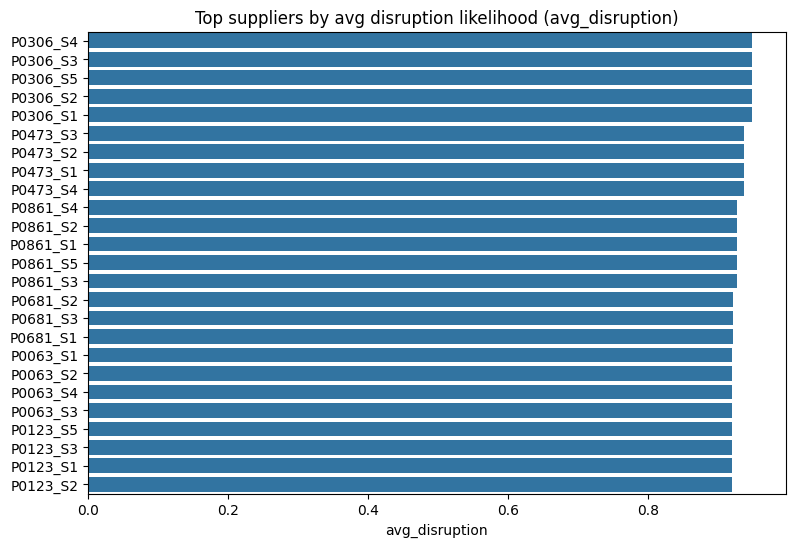

In [38]:
df = run_cypher_frame('''
MATCH (s:Supplier)-[r:SUPPLIES]->(:Product)
WITH s.id AS supplier_id,
     sum(r.delay_probability * toFloat(r.observation_count)) / sum(toFloat(r.observation_count)) AS avg_delay,
     sum(r.disruption_likelihood_score * toFloat(r.observation_count)) / sum(toFloat(r.observation_count)) AS avg_disruption,
     count(r) AS lanes
RETURN supplier_id, avg_delay, avg_disruption, lanes
ORDER BY avg_disruption DESC
LIMIT 25
''')
display(df)

# Plot supplier ranking by weighted disruption
import matplotlib.pyplot as plt

plot_df = df.sort_values('avg_disruption', ascending=False).copy()
plt.figure(figsize=(9, 6))
sns.barplot(data=plot_df, x='avg_disruption', y='supplier_id', orient='h')
plt.title('Top suppliers by weighted avg disruption likelihood (avg_disruption)')
plt.xlabel('avg_disruption')
plt.ylabel('')
plt.tight_layout()
plt.show()


#### Narrative (Q6)
Supplier risk ranking is computed from lane-level `SUPPLIES` metrics.

The averages are **weighted by `observation_count`**, so lanes backed by more raw evidence influence the supplier’s score more strongly.


### EDA Q7 — Supplier concentration vs delay risk
How does supplier product coverage (`product_count`) relate to weighted average delay risk?


,supplier_id,product_count,lanes,avg_delay
0,P0513_S1,1,30,0.887298
1,P0513_S2,1,30,0.887298
2,P0884_S3,1,31,0.874484
3,P0884_S1,1,31,0.874484
4,P0884_S4,1,31,0.874484
5,P0884_S5,1,31,0.874484
6,P0884_S2,1,31,0.874484
7,P0055_S1,1,26,0.867267
8,P0055_S3,1,26,0.867267
9,P0055_S2,1,26,0.867267


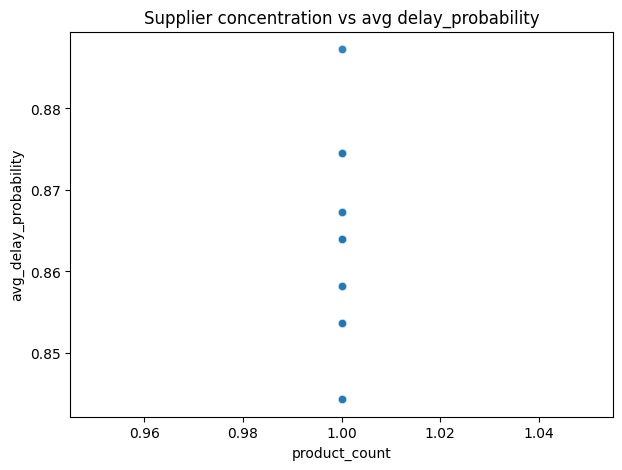

In [39]:
df = run_cypher_frame('''
MATCH (s:Supplier)-[r:SUPPLIES]->(p:Product)
WITH s.id AS supplier_id,
     count(DISTINCT p) AS product_count,
     sum(r.delay_probability * toFloat(r.observation_count)) / sum(toFloat(r.observation_count)) AS avg_delay,
     count(r) AS lanes
RETURN supplier_id, product_count, lanes, avg_delay
ORDER BY product_count DESC, avg_delay DESC
LIMIT 25
''')
display(df)

# Plot supplier concentration
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='product_count', y='avg_delay', alpha=0.7)
plt.title('Supplier concentration vs weighted avg delay_probability')
plt.xlabel('product_count')
plt.ylabel('weighted avg delay_probability')
plt.tight_layout()
plt.show()


#### Narrative (Q7)
This scatter plot compares a supplier’s **coverage** (how many distinct products it supplies) to its **risk** (weighted avg delay across its lanes).

Suppliers that combine high fan-out with high delay risk are strong candidates for audits and mitigation (e.g., backup sourcing or operational controls).


### EDA Q8 — Product exposure vs disruption likelihood
Which products are most exposed due to low supplier count and high weighted disruption?


,product_id,supplier_count,avg_delay,avg_disruption
0,P0568,2,0.739660,0.905609
1,P0947,2,0.603756,0.905447
2,P0825,2,0.696295,0.903512
3,P0026,2,0.833422,0.902887
4,P0164,2,0.815183,0.902628
5,P0393,2,0.672318,0.898303
6,P0898,2,0.661894,0.897339
7,P0618,2,0.670842,0.893282
8,P0201,2,0.597874,0.882216
9,P0526,2,0.723290,0.880605


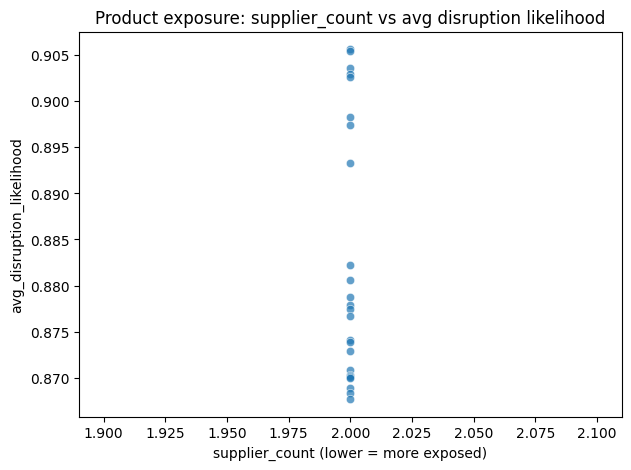

In [16]:
df = run_cypher_frame('''
MATCH (s:Supplier)-[r:SUPPLIES]->(p:Product)
WITH p.id AS product_id,
     count(DISTINCT s) AS supplier_count,
     sum(r.disruption_likelihood_score * toFloat(r.observation_count)) / sum(toFloat(r.observation_count)) AS avg_disruption,
     count(r) AS lanes
RETURN product_id, supplier_count, avg_disruption, lanes
ORDER BY supplier_count ASC, avg_disruption DESC
LIMIT 25
''')
display(df)

# Plot product exposure
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='supplier_count', y='avg_disruption', alpha=0.7)
plt.title('Product exposure: supplier_count vs weighted avg disruption likelihood')
plt.xlabel('supplier_count (lower = more exposed)')
plt.ylabel('weighted avg_disruption_likelihood')
plt.tight_layout()
plt.show()


#### Narrative (Q8)
Products with fewer supplier options are more exposed to disruption on a limited set of lanes.

This view highlights the overlap between **limited sourcing** (`supplier_count`) and **high disruption evidence** (weighted avg `disruption_likelihood_score`).


### EDA Q9 — Reliability vs delay (weighted)
At supplier level, how does weighted reliability relate to weighted delay probability?


,supplier_id,avg_reliability,avg_delay,lanes
0,P0513_S2,0.392453,0.887298,1
1,P0513_S1,0.392453,0.887298,1
2,P0884_S5,0.458917,0.874484,1
3,P0884_S1,0.458917,0.874484,1
4,P0884_S4,0.458917,0.874484,1
5,P0884_S2,0.458917,0.874484,1
6,P0884_S3,0.458917,0.874484,1
7,P0055_S2,0.403588,0.867267,1
8,P0055_S1,0.403588,0.867267,1
9,P0055_S3,0.403588,0.867267,1


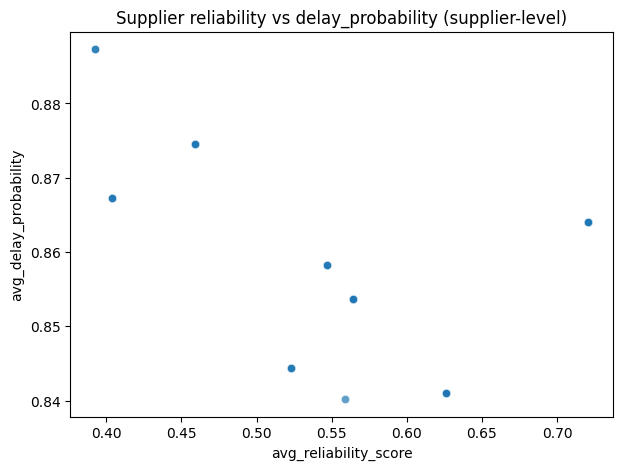

In [17]:
df = run_cypher_frame('''
MATCH (s:Supplier)-[r:SUPPLIES]->(:Product)
WITH s.id AS supplier_id,
     sum(r.supplier_reliability_score * toFloat(r.observation_count)) / sum(toFloat(r.observation_count)) AS avg_reliability,
     sum(r.delay_probability * toFloat(r.observation_count)) / sum(toFloat(r.observation_count)) AS avg_delay,
     count(r) AS lanes
RETURN supplier_id, avg_reliability, avg_delay, lanes
ORDER BY avg_delay DESC
LIMIT 30
''')
display(df)

# Plot reliability vs delay
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='avg_reliability', y='avg_delay', alpha=0.7)
plt.title('Supplier reliability vs weighted delay_probability (supplier-level)')
plt.xlabel('weighted avg_reliability_score')
plt.ylabel('weighted avg_delay_probability')
plt.tight_layout()
plt.show()


#### Narrative (Q9)
This view shows the trade-off between supplier reliability and delay risk.

Points with low reliability and high delay are the most concerning operational risk patterns.


### EDA Q10 — Operational drivers of delay (weighted)
Which operational drivers (`route_risk_level`, `customs_clearance_time`, `lead_time_days`) differ most between high-delay and low-delay lanes?


,avg_route_risk_high_delay,avg_route_risk_low_delay,avg_customs_high_delay,avg_customs_low_delay,avg_lead_high_delay,avg_lead_low_delay,n_high_delay_lanes,n_low_delay_lanes
0,6.996101,8.14063,2.296468,2.737598,5.216229,5.664487,3522,2


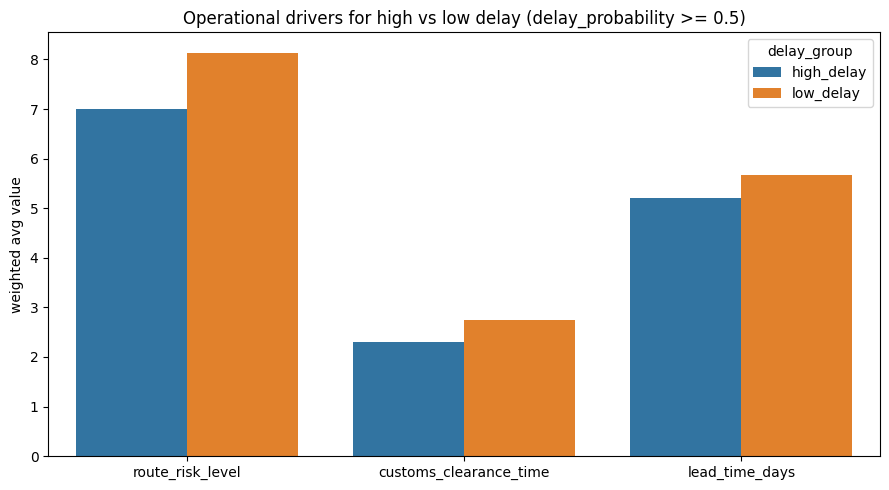

In [67]:
df = run_cypher_frame('''
MATCH ()-[r:SUPPLIES]->()
RETURN
  // weighted averages where weights are observation_count
  sum(CASE WHEN r.delay_probability >= 0.5 THEN r.route_risk_level * toFloat(r.observation_count) ELSE 0 END)
    / sum(CASE WHEN r.delay_probability >= 0.5 THEN toFloat(r.observation_count) ELSE 0 END)
    AS avg_route_risk_high_delay,

  sum(CASE WHEN r.delay_probability < 0.5 THEN r.route_risk_level * toFloat(r.observation_count) ELSE 0 END)
    / sum(CASE WHEN r.delay_probability < 0.5 THEN toFloat(r.observation_count) ELSE 0 END)
    AS avg_route_risk_low_delay,

  sum(CASE WHEN r.delay_probability >= 0.5 THEN r.customs_clearance_time * toFloat(r.observation_count) ELSE 0 END)
    / sum(CASE WHEN r.delay_probability >= 0.5 THEN toFloat(r.observation_count) ELSE 0 END)
    AS avg_customs_high_delay,

  sum(CASE WHEN r.delay_probability < 0.5 THEN r.customs_clearance_time * toFloat(r.observation_count) ELSE 0 END)
    / sum(CASE WHEN r.delay_probability < 0.5 THEN toFloat(r.observation_count) ELSE 0 END)
    AS avg_customs_low_delay,

  sum(CASE WHEN r.delay_probability >= 0.5 THEN r.lead_time_days * toFloat(r.observation_count) ELSE 0 END)
    / sum(CASE WHEN r.delay_probability >= 0.5 THEN toFloat(r.observation_count) ELSE 0 END)
    AS avg_lead_high_delay,

  sum(CASE WHEN r.delay_probability < 0.5 THEN r.lead_time_days * toFloat(r.observation_count) ELSE 0 END)
    / sum(CASE WHEN r.delay_probability < 0.5 THEN toFloat(r.observation_count) ELSE 0 END)
    AS avg_lead_low_delay,

  sum(CASE WHEN r.delay_probability >= 0.5 THEN 1 ELSE 0 END) AS n_high_delay_lanes,
  sum(CASE WHEN r.delay_probability < 0.5 THEN 1 ELSE 0 END) AS n_low_delay_lanes
''')
display(df)

# Plot operational drivers for high vs low delay
import matplotlib.pyplot as plt
import pandas as pd

row = df.iloc[0].to_dict()

plot_df = pd.DataFrame({
    'metric': ['route_risk_level', 'customs_clearance_time', 'lead_time_days'],
    'high_delay': [row['avg_route_risk_high_delay'], row['avg_customs_high_delay'], row['avg_lead_high_delay']],
    'low_delay':  [row['avg_route_risk_low_delay'], row['avg_customs_low_delay'], row['avg_lead_low_delay']],
})

plot_df_melt = plot_df.melt(
    id_vars='metric',
    value_vars=['high_delay', 'low_delay'],
    var_name='delay_group',
    value_name='value',
)

plt.figure(figsize=(9, 5))
sns.barplot(data=plot_df_melt, x='metric', y='value', hue='delay_group')
plt.title('Operational drivers for high vs low delay (delay_probability >= 0.5)')
plt.ylabel('weighted avg value')
plt.xlabel('')
plt.legend(title='delay_group')
plt.tight_layout()
plt.show()


#### Narrative (Q10)
This compares **lane-level operational drivers** between lanes with high vs low delay probability.

The averages are **weighted by `SUPPLIES.observation_count`**, so the comparisons reflect how much raw evidence supports each aggregated lane group.


### EDA Q11 — Observation-level risk class mix (raw evidence)
What is the distribution of `Observation.risk_classification` across all raw rows, and how does it compare to lane-mode risk distribution?


,risk_class,n
0,High Risk,84368
1,Moderate Risk,17783
2,Low Risk,10946


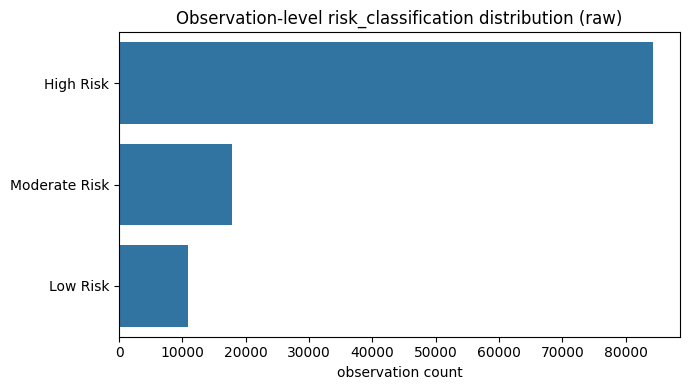

In [68]:
df = run_cypher_frame('''
MATCH (o:Observation)
RETURN o.risk_classification AS risk_class, count(*) AS n
ORDER BY n DESC
''')
display(df)

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
sns.barplot(data=df, x='n', y='risk_class', orient='h')
plt.title('Observation-level risk_classification distribution (raw)')
plt.xlabel('observation count')
plt.ylabel('')
plt.tight_layout()
plt.show()


#### Narrative (Q11)
This query reports the **raw evidence** risk mix from `Observation` nodes (one node per CSV row). Compare this with Q3 (lane-mode distribution) to understand how aggregation changes the apparent risk mix.


### EDA Q12 — Lane risk uncertainty / disagreement
Which supplier-product lanes show the most disagreement in risk evidence (i.e., `risk_high_share` closest to 0.5), and how much evidence supports them?


,supplier_id,product_id,observation_count,risk_high_share,distance_from_half,ambiguity_score
0,P0537_S1,P0537,26,0.500000,0.000000,1.000000
1,P0537_S2,P0537,26,0.500000,0.000000,1.000000
2,P0537_S3,P0537,26,0.500000,0.000000,1.000000
3,P0371_S1,P0371,27,0.518519,0.018519,0.962963
4,P0371_S2,P0371,27,0.518519,0.018519,0.962963
5,P0126_S1,P0126,21,0.476190,0.023810,0.952381
6,P0126_S2,P0126,21,0.476190,0.023810,0.952381
7,P0126_S3,P0126,21,0.476190,0.023810,0.952381
8,P0159_S1,P0159,32,0.531250,0.031250,0.937500
9,P0159_S2,P0159,32,0.531250,0.031250,0.937500


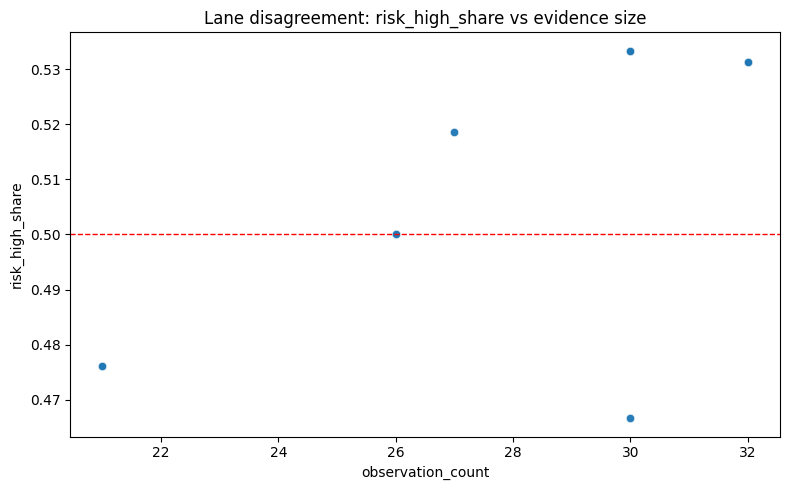

In [69]:
df = run_cypher_frame('''
MATCH (s:Supplier)-[r:SUPPLIES]->(p:Product)
WITH s.id AS supplier_id,
     p.id AS product_id,
     r.observation_count AS observation_count,
     r.risk_high_share AS risk_high_share,
     abs(r.risk_high_share - 0.5) AS distance_from_half
RETURN supplier_id,
       product_id,
       observation_count,
       risk_high_share,
       distance_from_half,
       (1.0 - 2.0 * distance_from_half) AS ambiguity_score
ORDER BY distance_from_half ASC, observation_count DESC
LIMIT 25
''')
display(df)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='observation_count', y='risk_high_share', alpha=0.8)
plt.axhline(0.5, color='red', linestyle='--', linewidth=1)
plt.title('Lane disagreement: risk_high_share vs evidence size')
plt.xlabel('observation_count')
plt.ylabel('risk_high_share')
plt.tight_layout()
plt.show()


#### Narrative (Q12)
Lanes near `risk_high_share = 0.5` are the most ambiguous because high-risk and non-high-risk evidence are mixed. Use `observation_count` to prioritize which ambiguous lanes deserve immediate investigation (high ambiguity + high evidence volume).


---
## Impact

- **Operational impact:** Helps prioritize supplier risk mitigation (e.g., diversification, audits, buffer inventory) by highlighting supplier/product nodes that concentrate high delay/disruption risk.
- **Business impact:** Supports better sourcing decisions and reduced disruption costs by identifying "critical" suppliers (network centrality) and high-risk supplier communities.
- **Analytical impact:** Demonstrates how graph modeling improves explainability for supply chain risk compared to purely tabular views (relationships are the signal).

---
## Project Goals

- **Project goal:** Create a supplier–product–country graph model and produce an analytic notebook with interpretable risk insights (rankings, segments/clusters, and vulnerability patterns).
- **Learning goal:** Demonstrate competence in building a knowledge graph in Neo4j and answering graph EDA questions using Cypher.

---
## Literature Review / Environmental Scan / Market Research

- [Kaggle – Supply chain dataset](https://www.kaggle.com/datasets/natasha0786/supply-chain-dataset/data)
- [Gurobi Optimisation Industry Solution Sheet – Supply Chain](https://cdn.gurobi.com/wp-content/uploads/IndustrySolutionSheet-SupplyChainMay2025-1.pdf?x81293)
- [Optimizing Supply Chain Decisions with Pyomo](https://medium.com/@brunoflombardi/optimizing-supply-chain-decisions-with-pyomo-a65b1c620ff4)

---
## Datasets

- **Primary dataset (used in this project):** [Kaggle – Supply chain dataset](https://www.kaggle.com/datasets/natasha0786/supply-chain-dataset/data).

  **Notes:** ~113k rows; stable identifiers `supplier_id`, `product_id`, `supplier_country`; risk/performance metrics (`delay_probability`, `disruption_likelihood_score`, `risk_classification`, `lead_time_days`, `shipping_costs`, `delivery_time_deviation`, etc.). This dataset is synthetic and global, spanning many `supplier_country` values (e.g., Greece, South Korea, Ethiopia, etc.), so it **does** support meaningful country-level aggregation in our analysis.

- **Related dataset (not used as the primary data source here):** [Kaggle – Logistics and Supply Chain Dataset](https://www.kaggle.com/datasets/datasetengineer/logistics-and-supply-chain-dataset/data), which describes a logistics network in Southern California with GPS and time-series metrics. This is the dataset we will treat as contextual background rather than the core analytic dataset for this project.

## GIS Visualization: Supply Chain Risk Map

The embedded map shows supplier locations across countries/regions from the dataset .

In [3]:
from IPython.display import HTML
import base64

# Read the full HTML file
with open("supply_chain_map.html", "r", encoding="utf-8") as f:
    map_html = f.read()

# Base64-encode it to embed as a data URL
html_b64 = base64.b64encode(map_html.encode("utf-8")).decode("ascii")

iframe_html = f"""
<iframe
    src="data:text/html;base64,{html_b64}"
    width="100%"
    height="600"
    style="border:none;"
></iframe>
"""

HTML(iframe_html)

## Metric Definitions and Assumptions

The primary dataset includes operational and risk-related columns. Below we describe how each metric is typically derived and how we interpret it in this project. Where the Kaggle documentation does not provide an exact formula, we base our descriptions on common industry practice and treat them as informed assumptions.

- **warehouse_inventory_level**  
  Approximate quantity of product units stored at the warehouse at the time of the record, derived from inventory transactions. Higher values imply more buffer stock but also higher holding costs.

- **handling_equipment_availability**  
  Fraction of time that key handling equipment (e.g., forklifts, cranes, conveyors) is available and not out of service. Typically computed as:

$$
\text{availability} = \frac{\text{uptime}}{\text{uptime} + \text{downtime}}
$$

  Values closer to 1 indicate highly available equipment.

- **order_fulfillment_status**  
  A normalized indicator of how fully and on-time an order was fulfilled. Often derived from OTIF (On Time In Full) metrics, e.g. proportion of ordered quantity delivered within the promised window. Higher values mean better fulfillment performance.

- **weather_condition_severity**  
  Index summarizing how adverse the weather was along the route or at relevant locations, constructed from weather feeds (precipitation, wind, visibility, storms). Typically scaled between 0 (benign) and 1 (severe).

- **shipping_costs**  
  Total cost of transporting the shipment, including line-haul, fuel, tolls, and handling charges. Derived from operational cost records or a costing model.

- **supplier_reliability_score**  
  Measure of how consistently a supplier delivers on time and to specification. Commonly calculated from historical deliveries as the on-time delivery ratio, possibly scaled to 0–1 or 0–100:

$$
\text{score} = \frac{\text{on-time deliveries}}{\text{total deliveries}}
$$

  Higher scores mean more reliable suppliers.

- **lead_time_days**  
  Time between order placement and delivery, in days. Computed as (delivery timestamp – order timestamp) converted to days.

- **historical_demand**  
  Historical or forecasted demand volume for the product in the relevant market/time window, typically aggregated as a moving average or recent-period sum from order history.

- **cargo_condition_status**  
  Indicator of whether the cargo remained within acceptable conditions (e.g., temperature, humidity, shock) during transit. Derived from sensors or inspection logs; often encoded as a score (0–1) or discrete categories (e.g., Good / Warning / Damaged).

- **route_risk_level**  
  Composite measure of inherent risk on a specific route, built from factors like historical incidents (accidents, theft), congestion, infrastructure quality, crime, and weather exposure. Typically computed as a weighted sum of standardized risk factors and then mapped to Low/Moderate/High or numeric bands. Higher values = riskier routes.

- **customs_clearance_time**  
  Time spent in customs for international shipments, often measured directly from event timestamps (arrival at customs vs clearance) and expressed in hours or days. Higher values imply greater border-processing friction.

- **disruption_likelihood_score**  
  Modeled probability that a shipment on this lane/time will experience a disruptive event (e.g., strike, severe weather, route closure). Usually produced by a predictive model:

$$
\text{score} \approx P(\text{disruption} \mid \text{route, time, external factors})
$$

  Higher scores indicate greater risk of major disruption.

- **delay_probability**  
  Probability that the shipment will be delivered late relative to its promised lead time, estimated from historical performance or a predictive model:

$$
\text{delay\_probability} \approx P(\text{actual lead time} > \text{promised lead time})
$$

  Values near 1 mean very high lateness risk.

- **risk_classification**  
  Categorical label (e.g., Low / Moderate / High Risk) summarizing overall risk for the shipment or lane, typically derived from thresholds or a classifier that combines delay_probability, disruption_likelihood_score, route_risk_level, and other signals.

- **delivery_time_deviation**  
  Difference between actual and planned delivery times:

$$
\text{deviation} = \text{actual delivery time} - \text{planned delivery time}
$$

  Positive values indicate lateness; negative values indicate early delivery.

- **product_id, supplier_id, supplier_country**  
  Stable identifiers for products and suppliers, and the supplier’s country. These are used as node keys and grouping variables (e.g., country-level aggregation) in our graph model.


---
## Design Concepts

The design is a knowledge graph that models how suppliers connect to products and how supplier geography relates to risk outcomes.

Rather than analyzing each row as an isolated "instance," the graph emphasizes shared suppliers and shared products, enabling network-style insights such as:

- Dependency concentration (many products tied to a few suppliers)
- Risk clustering (groups of suppliers with similar risk profiles and shared product coverage)

The output will include Cypher-based EDA, deeper analytical queries, and at least one GDS-based ranking or clustering result with narrative interpretation.

---
## Conceptual Architecture

### Services/tools

- Neo4j Desktop (local DBMS)
- APOC (schema exploration convenience)
- Neo4j Graph Data Science (GDS)
- Jupyter Notebook + Python driver for reproducible execution and charts

### Data + database considerations

- Create uniqueness constraints for `:Supplier(id)` and `:Product(id)` to ensure clean MERGE ingestion.
- Store row-level risk metrics primarily on relationships `(:Supplier)-[:SUPPLIES]->(:Product)` to represent the risk/performance of that supplier–product pairing.
- Create `:Country(name)` nodes and connect suppliers via `(:Supplier)-[:LOCATED_IN]->(:Country)` for geography-based analysis.

### Processing/server architecture

- Local single-node Neo4j instance is sufficient (dataset size is moderate).
- Use batching in LOAD CSV to avoid memory spikes.

---
## Analytical Design

### Metrics and signals

- **Supplier risk:** mean/median `delay_probability`, mean `disruption_likelihood_score`, distribution of `risk_classification`
- **Product exposure:** number of distinct suppliers per product (dependency diversification) and risk-weighted exposure
- **Geography:** aggregate risk by `supplier_country`
- **Network criticality:** centrality scores (e.g., degree/PageRank/betweenness) in projections such as Supplier–Product or Supplier–Supplier similarity

### Audience

- Supply chain analysts / operations leadership (risk mitigation planning)
- Data/analytics stakeholders evaluating where to invest in resilience improvements

### Outputs and display

- Ranked lists (top risky suppliers, most exposed products, highest-risk countries)
- Distribution plots (risk classification mix by country; supplier reliability vs delay probability)
- GDS outputs (top nodes by centrality; communities with risk profiles)

---
## Sample Question Set

### EDA

- Counts of nodes/relationships after ingestion; distinct labels and rel types
- How many suppliers, products, countries?
- Top 10 suppliers by number of products supplied
- Risk classification distribution overall and by country
- Summary stats of `lead_time_days`, `shipping_costs`, `delay_probability`
- Products with the fewest suppliers (single-sourcing risk)
- Countries with highest average disruption likelihood
- Correlation-style inspection: supplier reliability vs delay probability (bucketed)

### Deeper Cypher 

- Identify **"critical suppliers":** suppliers that supply many products AND have high delay/disruption metrics
- Identify **"high-exposure products":** products whose supplier set is small and/or skewed toward high-risk suppliers
- **Country vulnerability:** countries where high-risk suppliers dominate critical products
- **Risk concentration:** find product groups that share many of the same suppliers (dependency clusters)

### GDS 

- **PageRank or Degree** on a projected Supplier–Product graph (or Supplier–Supplier co-supply graph) using `delay_probability` or `shipping_costs` as weights, to rank the most "influential/critical" suppliers in the dependency network.
- **Louvain community detection** to find clusters of suppliers/products; compare community risk profiles.

---
## Data Exchange/Processing Framework

### Processing steps

1. Validate CSV schema and data types (numeric parsing, categorical fields).
2. Ingest into Neo4j using LOAD CSV WITH HEADERS:
   - MERGE suppliers, products, countries
   - MERGE/CREATE SUPPLIES relationships with risk/performance properties
3. Run EDA queries to verify schema correctness and scale.
4. Run deeper Cypher questions and capture outputs.
5. Run at least one GDS workflow (estimate → run → interpret), write results back (optional), and report findings.

### Data flow

`CSV → Neo4j (constraints + ingestion) → Cypher EDA/analytics → GDS projection/algorithm → Notebook tables/plots + interpretation`

---
## Additional Comments

The dataset is "instance-based," so the graph model will treat each row as evidence of a supplier–product relationship with associated risk/performance properties.

Where multiple rows exist per supplier–product pair, relationship properties will be aggregated (e.g., mean delay probability, mean disruption likelihood, count of observations).

---
## References and Hyperlinks

- [Neo4j Graph Data Science docs](https://neo4j.com/docs/graph-data-science/current/)
- [Neo4j Cypher manual](https://neo4j.com/docs/cypher-manual/current/)
- [Kaggle – Supply chain dataset](https://www.kaggle.com/datasets/natasha0786/supply-chain-dataset/data) *(primary)*
- [Kaggle – Logistics and Supply Chain Dataset](https://www.kaggle.com/datasets/datasetengineer/logistics-and-supply-chain-dataset/data) *(related; for other similar projects)*
- [Barabási, A.-L. – Network Science (open book)](http://networksciencebook.com/)
- [Gurobi Optimisation Industry Solution Sheet](https://cdn.gurobi.com/wp-content/uploads/IndustrySolutionSheet-SupplyChainMay2025-1.pdf?x81293)
- [Optimizing Supply Chain Decisions with Pyomo](https://medium.com/@brunoflombardi/optimizing-supply-chain-decisions-with-pyomo-a65b1c620ff4)

